# SearchSense
## Exploratory Data Analysis

**Dataset:** Criteo Display Advertising Challenge (500K sample)  
**Goal:** Understand click behavior patterns before modeling  
**Author:** Ramya Manasa Amancherla

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Column names: 1 label + 13 numerical + 26 categorical
col_names = ["click"] + [f"num_{i}" for i in range(13)] + [f"cat_{i}" for i in range(26)]

# Load 500K rows from Criteo training set
df = pd.read_csv("data/dac/train.txt", sep="\t", header=None, names=col_names, nrows=500_000)

print(f"Shape: {df.shape}")
print(f"Click rate: {df['click'].mean():.3f}")
print(f"Total clicks: {df['click'].sum():,}")
print(f"Total non-clicks: {(df['click']==0).sum():,}")

Shape: (500000, 40)
Click rate: 0.256
Total clicks: 127,915
Total non-clicks: 372,085


## 1. Click Rate Analysis
Understanding the distribution of our target variable — are people clicking on ads?

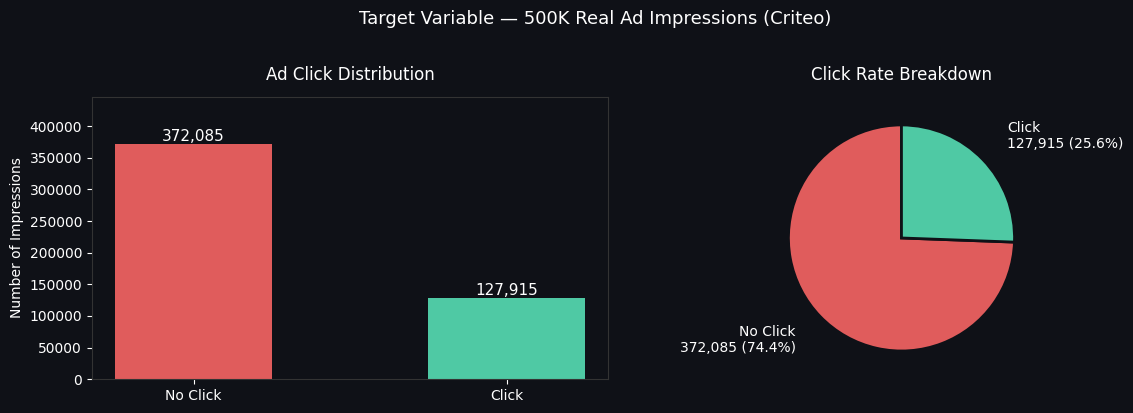

In [6]:
# Compute click distribution from dataset
click_counts = df['click'].value_counts().sort_index()
no_click = click_counts[0]
click = click_counts[1]
total = len(df)
click_rate = click / total * 100
no_click_rate = no_click / total * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('#0f1117')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

# Bar chart — absolute counts
bars = axes[0].bar(
    ["No Click", "Click"],
    [no_click, click],
    color=["#e05c5c", "#4fc9a4"],
    width=0.5,
    edgecolor='none'
)
axes[0].set_title("Ad Click Distribution", color='white', pad=12)
axes[0].set_ylabel("Number of Impressions", color='white')
axes[0].set_ylim(0, no_click * 1.2)

for bar, val in zip(bars, [no_click, click]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{val:,}', ha='center', color='white', fontsize=11)

# Pie chart — percentage breakdown
axes[1].pie(
    [no_click, click],
    labels=[f"No Click\n{no_click:,} ({no_click_rate:.1f}%)", 
            f"Click\n{click:,} ({click_rate:.1f}%)"],
    colors=["#e05c5c", "#4fc9a4"],
    startangle=90,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2),
    textprops=dict(color='white', fontsize=10),
    labeldistance=1.3
)
axes[1].set_title("Click Rate Breakdown", color='white', pad=12)

plt.suptitle("Target Variable — 500K Real Ad Impressions (Criteo)", 
             fontsize=13, color='white', y=1.02)
plt.tight_layout()
plt.savefig("data/click_distribution.png", dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## 2. Missing Value Analysis
Missing data distribution across 13 numerical features, 500K sample.

Feature  Missing Count  Missing %
 num_11         383906      76.78
  num_0         211629      42.33
  num_9         211629      42.33
  num_3         128491      25.70
 num_12         128491      25.70
  num_2         117905      23.58
  num_5         113243      22.65
  num_6          21029       4.21
  num_8          21029       4.21
 num_10          21029       4.21
  num_4          14625       2.92
  num_7            386       0.08
  num_1              0       0.00


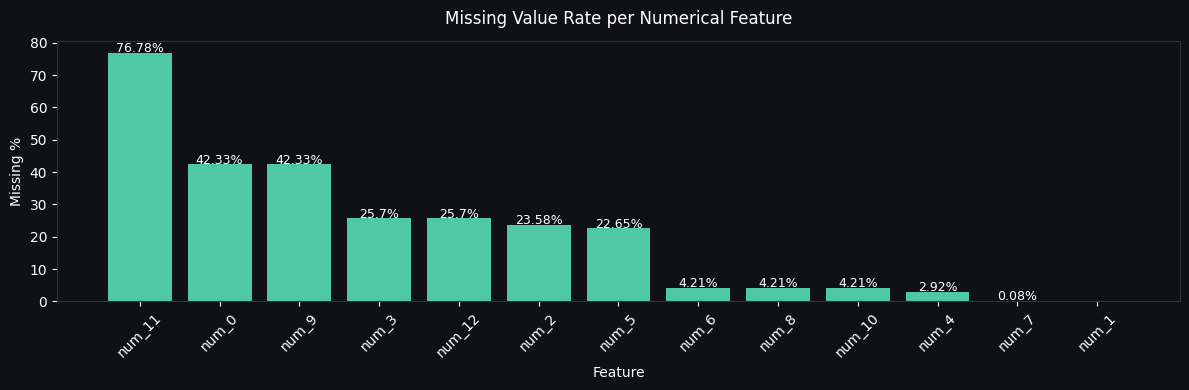

In [7]:
# Compute missing value percentage per numerical feature
num_cols = [f'num_{i}' for i in range(13)]
missing = df[num_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Feature': num_cols,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)

print(missing_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

bars = ax.bar(
    missing_df['Feature'],
    missing_df['Missing %'],
    color='#4fc9a4',
    edgecolor='none'
)

# Label each bar with percentage
for bar, val in zip(bars, missing_df['Missing %']):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val}%', ha='center', color='white', fontsize=9)

ax.set_title("Missing Value Rate per Numerical Feature", color='white', pad=12)
ax.set_ylabel("Missing %", color='white')
ax.set_xlabel("Feature", color='white')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/missing_values.png", dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

### Key Findings
The missing data is not random. num_11 is missing in nearly 77% of rows, making it effectively 
unusable as a feature. num_0 and num_9 share an identical missing rate of 42.3%, which suggests 
they are likely derived from the same underlying signal. Features like num_6, num_8, and num_10 
cluster together at 4.2% missing, again pointing to a shared origin. num_1 is the only feature 
with no missing values at all, making it the most structurally reliable signal in the dataset.

## 3. Numerical Feature Distributions
Distribution of numerical features split by click vs no-click, to identify which features carry signal.

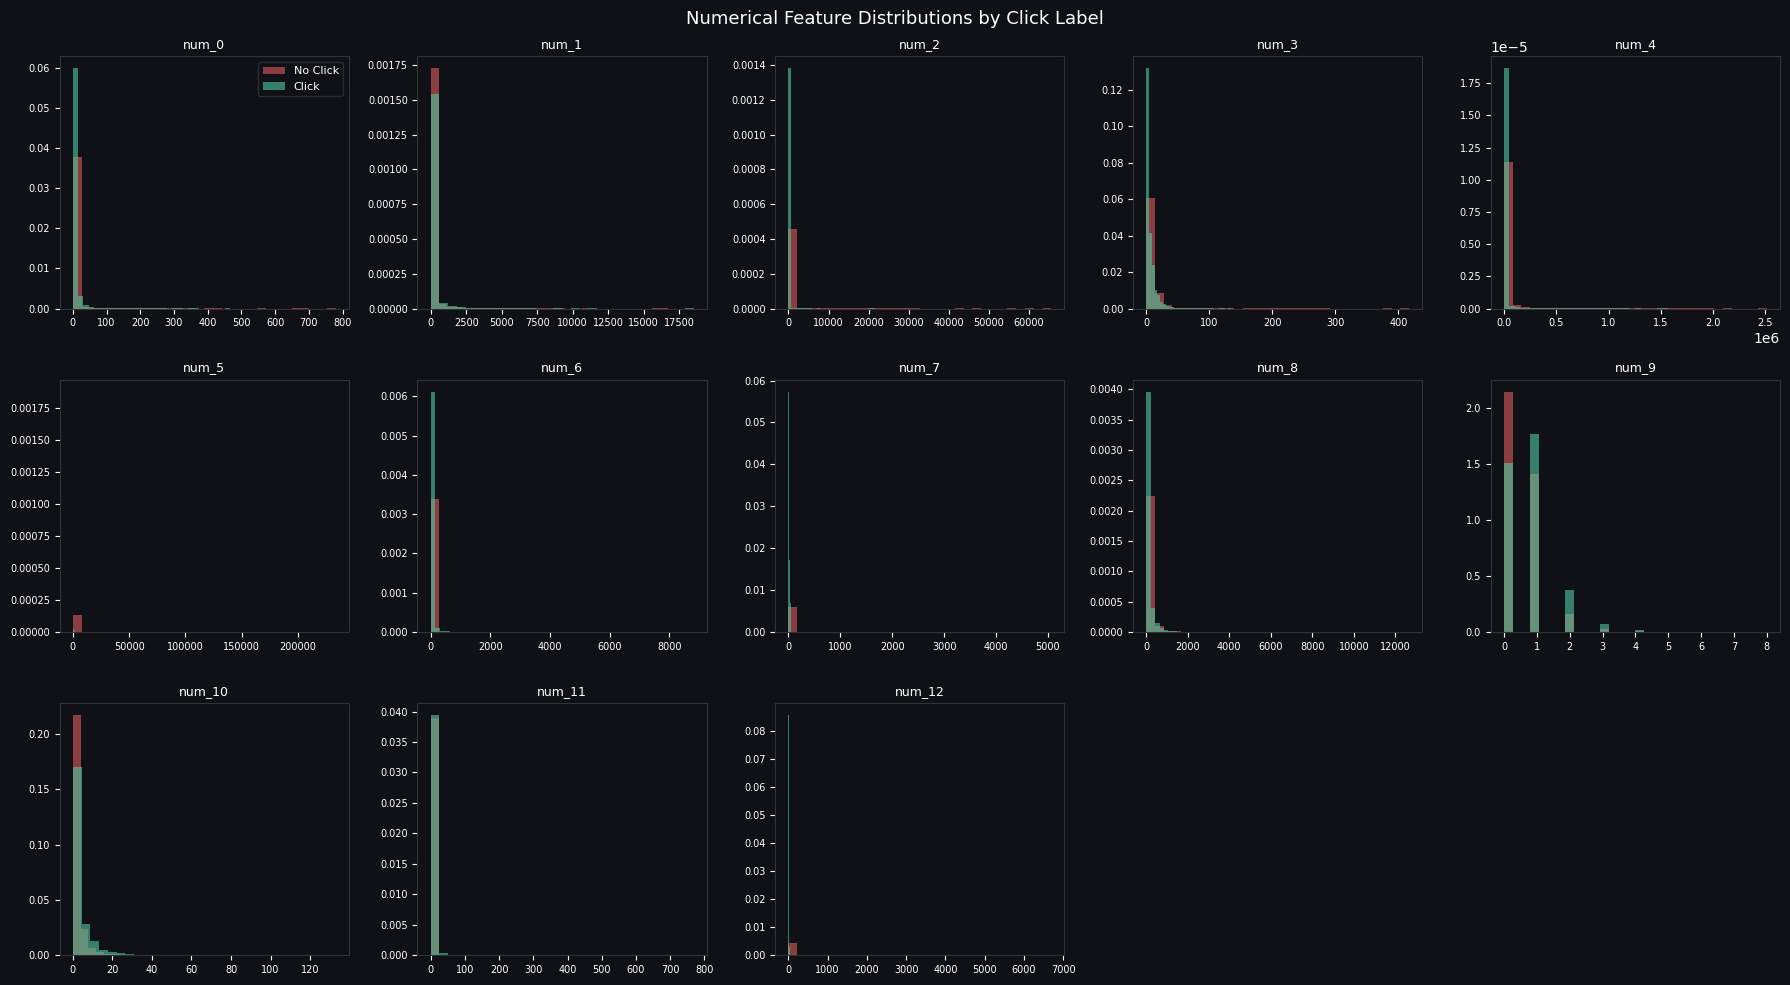

In [8]:
# Compare feature distributions for clicked vs non-clicked ads
num_cols = [f'num_{i}' for i in range(13)]
clicked = df[df['click'] == 1]
not_clicked = df[df['click'] == 0]

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.set_facecolor('#0f1117')
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    
    # Plot distributions for click=0 and click=1
    ax.hist(not_clicked[col].dropna(), bins=30, alpha=0.6, 
            color='#e05c5c', label='No Click', density=True)
    ax.hist(clicked[col].dropna(), bins=30, alpha=0.6, 
            color='#4fc9a4', label='Click', density=True)
    ax.set_title(col, color='white', fontsize=9)

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8, labelcolor='white', 
               facecolor='#0f1117', edgecolor='#333333')

plt.suptitle("Numerical Feature Distributions by Click Label", 
             color='white', fontsize=13)
plt.tight_layout()
plt.savefig("data/feature_distributions.png", dpi=150, 
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

### Key Findings
Most features are heavily right-skewed, meaning a small number of ads have extremely high values 
while the majority cluster near zero. This is typical of ad frequency and count-based signals. 
The separation between the red and green distributions is visible in num_1, num_2, and num_7, 
meaning clicked and non-clicked ads genuinely differ on those features. Those are likely our 
strongest predictors. Features like num_5 and num_10 show almost identical distributions for 
both classes, suggesting they carry weak predictive signal.

## 4. Correlation Analysis
Which numerical features are most correlated with click behavior?

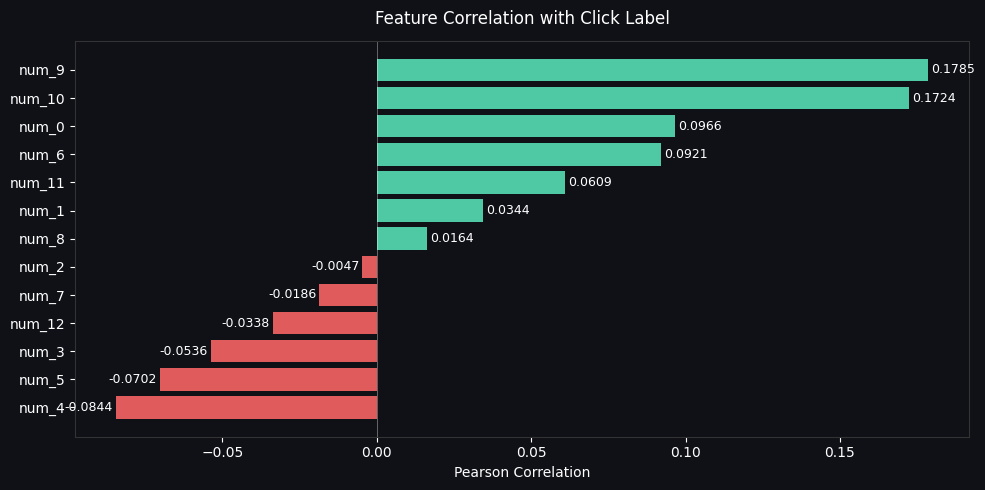

In [9]:
# Compute correlation of numerical features with click label
num_cols = [f'num_{i}' for i in range(13)]
correlations = df[num_cols + ['click']].corr()['click'].drop('click').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

colors = ['#e05c5c' if x < 0 else '#4fc9a4' for x in correlations.values]

bars = ax.barh(correlations.index, correlations.values, color=colors, edgecolor='none')

for bar, val in zip(bars, correlations.values):
    ax.text(val + 0.001 if val >= 0 else val - 0.001, 
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', 
            ha='left' if val >= 0 else 'right',
            color='white', fontsize=9)

ax.axvline(x=0, color='white', linewidth=0.5, alpha=0.5)
ax.set_title("Feature Correlation with Click Label", color='white', pad=12)
ax.set_xlabel("Pearson Correlation", color='white')

plt.tight_layout()
plt.savefig("data/correlations.png", dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

### Key Findings
num_9 and num_10 are the strongest positive predictors of clicks, with correlations of 0.18 and 
0.17 respectively. num_0 and num_6 also show meaningful positive signal. On the negative side, 
num_4 and num_5 are inversely correlated with clicks, meaning higher values in those features 
actually reduce click probability. Features near zero like num_2 and num_8 carry almost no 
linear signal and may be dropped or deprioritized during feature selection.